<a href="https://colab.research.google.com/github/Thanjaivalavan/M2-GenAI-AgenticAI/blob/main/MLmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
!wget -q https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip
!unzip -q "sms+spam+collection.zip"

In [ ]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

In [ ]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.shape

(5572, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df["label"].value_counts()

,count
label,
ham,4825
spam,747


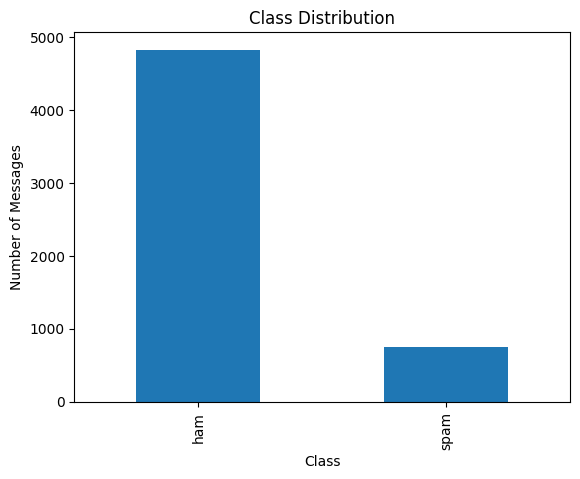

In [ ]:
df["label"].value_counts().plot(
    kind="bar",
    title="Class Distribution"
)

plt.xlabel("Class")
plt.ylabel("Number of Messages")
plt.show()

In [ ]:
df.isnull().sum()

,0
label,0
message,0


In [ ]:
df.duplicated().sum()

np.int64(403)

In [ ]:
print("HAM EXAMPLES")
print(df[df["label"] == "ham"]["message"].head(5).to_string(index=False))

print("\nSPAM EXAMPLES")
print(df[df["label"] == "spam"]["message"].head(5).to_string(index=False))

HAM EXAMPLES
Go until jurong point, crazy.. Available only i...
                     Ok lar... Joking wif u oni...
 U dun say so early hor... U c already then say...
Nah I don't think he goes to usf, he lives arou...
Even my brother is not like to speak with me. T...

SPAM EXAMPLES
Free entry in 2 a wkly comp to win FA Cup final...
FreeMsg Hey there darling it's been 3 week's no...
WINNER!! As a valued network customer you have ...
Had your mobile 11 months or more? U R entitled...
SIX chances to win CASH! From 100 to 20,000 pou...


In [ ]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.shape

(5572, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df["label"].value_counts()

,count
label,
ham,4825
spam,747


In [ ]:
df.isnull().sum()

,0
label,0
message,0


In [ ]:
df.duplicated().sum()

np.int64(403)

In [ ]:
df[df.duplicated(keep=False)].sort_values("message").head(20)

,label,message
505,spam,+123 Congratulations - in this week's competit...
2124,spam,+123 Congratulations - in this week's competit...
2344,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1373,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2163,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1050,spam,18 days to Euro2004 kickoff! U will be kept in...
2719,spam,18 days to Euro2004 kickoff! U will be kept in...
2044,spam,4mths half price Orange line rental & latest c...
389,spam,4mths half price Orange line rental & latest c...
1779,ham,7 wonders in My WORLD 7th You 6th Ur style 5th...


In [ ]:
df[df.duplicated(keep=False)]["label"].value_counts()

,count
label,
ham,503
spam,181


In [ ]:
df.groupby("message")["label"].nunique().value_counts()

,count
label,
1,5169


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(5169, 2)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["label"].value_counts()

,count
label,
ham,4516
spam,653


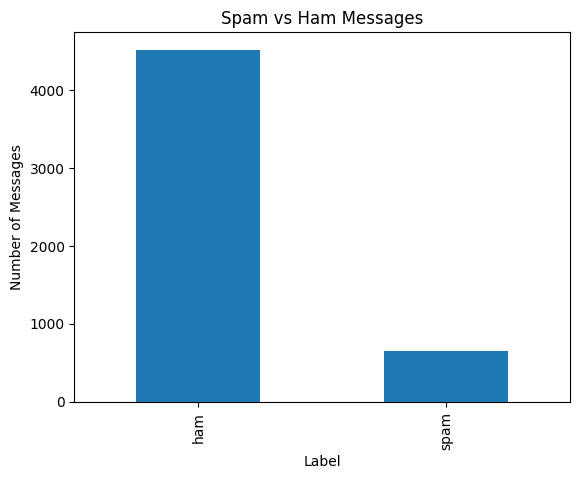

In [ ]:
df["label"].value_counts().plot(
    kind="bar",
    title="Spam vs Ham Messages"
)

plt.xlabel("Label")
plt.ylabel("Number of Messages")
plt.show()

In [ ]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [ ]:
X = df["message"]
y = df["label"]

In [ ]:
print("Dataset shape:", df.shape)
print("Missing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["label"].value_counts())

Dataset shape: (5169, 2)
Missing values:
label      5169
message       0
dtype: int64

Class distribution:
Series([], Name: count, dtype: int64)


In [ ]:
df.head()

,label,message
0,NaN,"Go until jurong point, crazy.. Available only ..."
1,NaN,Ok lar... Joking wif u oni...
2,NaN,Free entry in 2 a wkly comp to win FA Cup fina...
3,NaN,U dun say so early hor... U c already then say...
4,NaN,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
X = df["message"]
y = df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

ValueError: Input y contains NaN.

In [ ]:
print(y.unique())
print(y.isnull().sum())

[nan]
5169


In [ ]:
print(df["label"].unique())
print(df["label"].value_counts(dropna=False))

[nan]
label
NaN    5169
Name: count, dtype: int64


In [ ]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [ ]:
y = y.dropna()

In [ ]:
print("df labels:")
print(df["label"].value_counts(dropna=False))

print("\ny:")
print(y.value_counts(dropna=False))

print("\nNumber of NaNs in y:", y.isna().sum())

df labels:
label
NaN    5169
Name: count, dtype: int64

y:
Series([], Name: count, dtype: int64)

Number of NaNs in y: 0


In [ ]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [ ]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

In [ ]:
print(df.shape)
print(df["label"].value_counts())

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df.shape)
print(df.duplicated().sum())

(5169, 2)
0


In [ ]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [ ]:
print(df["label"].value_counts(dropna=False))

label
0    4516
1     653
Name: count, dtype: int64


In [ ]:
print("NaN labels:", df["label"].isna().sum())

NaN labels: 0


In [ ]:
X = df["message"]
y = df["label"]

In [ ]:
X = df["message"]
y = df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training samples: 4135
Testing samples: 1034

Training labels:
label
0    3613
1     522
Name: count, dtype: int64

Testing labels:
label
0    903
1    131
Name: count, dtype: int64


In [ ]:
print(df["label"].value_counts(dropna=False))
print(X.shape, y.shape)
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

label
0    4516
1     653
Name: count, dtype: int64
(5169,) (5169,)
(4135,) (1034,)
label
0    3613
1     522
Name: count, dtype: int64
label
0    903
1    131
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer()

In [ ]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [ ]:
fit_transform()

NameError: name 'fit_transform' is not defined

In [ ]:
fit_transform()

NameError: name 'fit_transform' is not defined

In [ ]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)

In [ ]:
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer()

In [ ]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [ ]:
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4135, 7680)
Testing shape: (1034, 7680)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)
print(y_pred[:20])

(4135, 7680)
(1034, 7680)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9526112185686654


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[903   0]
 [ 49  82]]


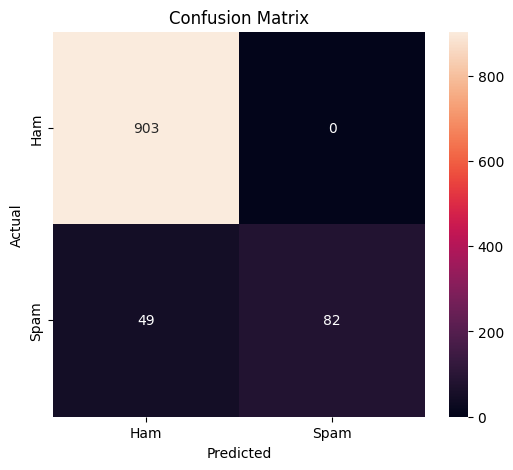

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 1.0


In [ ]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.6259541984732825


In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

Accuracy : 0.9526112185686654
Precision: 1.0
Recall   : 0.6259541984732825
F1-score : 0.7699530516431925


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       1.00      0.63      0.77       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.96      0.95      0.95      1034



In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.9526112185686654
Precision: 1.0
Recall   : 0.6259541984732825
F1-score : 0.7699530516431925


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[903   0]
 [ 49  82]]


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       1.00      0.63      0.77       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.96      0.95      0.95      1034



In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("===== MODEL EVALUATION =====")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred))

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"]
    )
)

===== MODEL EVALUATION =====
Accuracy : 0.9526112185686654
Precision: 1.0
Recall   : 0.6259541984732825
F1-score : 0.7699530516431925

===== CONFUSION MATRIX =====
[[903   0]
 [ 49  82]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       1.00      0.63      0.77       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.96      0.95      0.95      1034



In [ ]:
def predict_spam(message):

    # Convert text into TF-IDF representation
    message_tfidf = vectorizer.transform([message])

    # Predict class
    prediction = model.predict(message_tfidf)[0]

    # Get probability
    probability = model.predict_proba(message_tfidf)[0]

    if prediction == 1:
        result = "SPAM"
    else:
        result = "HAM"

    return result, probability

In [ ]:
message = "Congratulations! You have won a free prize. Click now to claim!"

result, probability = predict_spam(message)

print("Message:", message)
print("Prediction:", result)
print("Probabilities:", probability)

Message: Congratulations! You have won a free prize. Click now to claim!
Prediction: SPAM
Probabilities: [0.14596285 0.85403715]


In [ ]:
message = "Hi, are we still meeting at 5 pm today?"

result, probability = predict_spam(message)

print("Message:", message)
print("Prediction:", result)
print("Probabilities:", probability)

Message: Hi, are we still meeting at 5 pm today?
Prediction: HAM
Probabilities: [0.99746703 0.00253297]


In [ ]:
message = "URGENT! You have won 50000 dollars. Call now to claim your reward!"

result, probability = predict_spam(message)

print("Message:", message)
print("Prediction:", result)
print("Probabilities:", probability)

Message: URGENT! You have won 50000 dollars. Call now to claim your reward!
Prediction: SPAM
Probabilities: [0.34533144 0.65466856]


In [ ]:
message = "Congratulations on your excellent exam results!"

result, probability = predict_spam(message)

print("Message:", message)
print("Prediction:", result)
print("Probabilities:", probability)

Message: Congratulations on your excellent exam results!
Prediction: HAM
Probabilities: [0.82839122 0.17160878]


In [ ]:
while True:

    message = input("\nEnter a message (or type 'quit'): ")

    if message.lower() == "quit":
        print("Exiting spam detector.")
        break

    result, probability = predict_spam(message)

    print("\nPrediction:", result)

    if result == "SPAM":
        print("Spam probability:", round(probability[1] * 100, 2), "%")
    else:
        print("Ham probability:", round(probability[0] * 100, 2), "%")


Enter a message (or type 'quit'): quit
Exiting spam detector.


In [ ]:
import joblib

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(model, "spam_classifier.pkl")

print("Model and vectorizer saved.")

Model and vectorizer saved.


In [ ]:
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")
loaded_model = joblib.load("spam_classifier.pkl")

In [ ]:
test_message = [
    "Congratulations! You have won a free prize!"
]

test_vector = loaded_vectorizer.transform(test_message)

prediction = loaded_model.predict(test_vector)

print("Prediction:", prediction)

Prediction: [1]


In [ ]:
print(model)

MultinomialNB()


In [ ]:
print("Class log prior:")
print(model.class_log_prior_)

Class log prior:
[-0.13494888 -2.06957502]


In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
print("Actual:")
print(y_test.iloc[:20].values)

print("\nPredicted:")
print(y_pred[:20])

Actual:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Predicted:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
new_message = [
    "Congratulations! You have won a free prize. Click now to claim!"
]

In [ ]:
new_message_tfidf = vectorizer.transform(new_message)

In [ ]:
prediction = model.predict(new_message_tfidf)

In [ ]:
print(prediction)

[1]


In [ ]:
if prediction[0] == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: HAM")

Prediction: SPAM


In [ ]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("First 20 actual labels:")
print(y_test.iloc[:20].values)

print("\nFirst 20 predictions:")
print(y_pred[:20])

First 20 actual labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
new_message = [
    "Congratulations! You have won a free prize. Click now to claim!"
]

new_message_tfidf = vectorizer.transform(new_message)

prediction = model.predict(new_message_tfidf)
probability = model.predict_proba(new_message_tfidf)

print("Prediction:", prediction)
print("Probability:", probability)
print("Classes:", model.classes_)

Prediction: [1]
Probability: [[0.14596285 0.85403715]]
Classes: [0 1]
